# Determining Drag Area Coefficient from Cruising Tests

**Author:** Ryan Huang

**Date:** 2026-05-16

**Relevant Links:**
- [Monday Item](https://ubcsolar26.monday.com/boards/9565353662/views/211183038/pulses/11675714971)
- This analysis reuses some code from the [2025 Brightside Cruise Test](https://github.com/UBC-Solar/data_analysis/blob/main/v3/motor_analysis/motor_testing_april_6.ipynb)

The goal of this analysis is to produce a reasonable CdA (drag coefficient * area) value. This is done through analyzing cruising tests that were performed on Apr 2, 2026, at the McArthur Glen Designer Outlet parking lot. 

6 cruising tests were performed, but this analysis will only use the first 4 as regenerative braking was likely active for the last 2 (during the tests, Pack Current had negative values on InfluxDB, although RegenEnabled read 0)

## Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
import dill
from data_tools.collections import TimeSeries
from data_tools.query import DBClient
from datetime import datetime
from pathlib import Path
from scipy import stats


## Data Acquisition

First, we extract the four cruise tests done without regenerative braking.

In [8]:
LOAD_FROM_FILE = False 
DATA_DIR = Path("data")
speed_file = DATA_DIR / "cruise_motor_speeds.bin"
current_file = DATA_DIR / "cruise_pack_currents.bin"
brake_file = DATA_DIR / "cruise_brake_presseds.bin"

# manually identified cruising test windows
START_TIMES = [datetime.fromisoformat("2026-04-02T20:02:25Z"),
                   datetime.fromisoformat("2026-04-02T20:07:05Z"),
                   datetime.fromisoformat("2026-04-02T20:25:57Z"),
                   datetime.fromisoformat("2026-04-02T20:35:34Z"),]
    
STOP_TIMES = [datetime.fromisoformat("2026-04-02T20:03:02Z"),
                datetime.fromisoformat("2026-04-02T20:07:31Z"),
                datetime.fromisoformat("2026-04-02T20:26:38Z"),
                datetime.fromisoformat("2026-04-02T20:36:12Z"),]

if LOAD_FROM_FILE:
    
    # Loading from file does not work currently because TimeSeries cannot be serialized
    
    with open(speed_file, "rb") as f:
        cruise_speeds: list[TimeSeries] = dill.load(f)
    with open(current_file, "rb") as f:
        cruise_pack_currents: list[TimeSeries] = dill.load(f)
    with open(brake_file, "rb") as f:
        cruise_brake_presseds: list[TimeSeries] = dill.load(f)

else:
    client = DBClient()
    PACK_CURRENT_THRESHOLD = 0.10682  # pack current never reads 0; its lowest value is this constant (constant is rounded up here)

    cruise_speeds: list[TimeSeries] = []
    cruise_pack_currents: list[TimeSeries] = []      # pack current tells us when each test starts
    cruise_brake_presseds: list[TimeSeries] = []     # brake pressed tells us when each test ends

    for start, stop in zip(START_TIMES, STOP_TIMES):
        motor_rotating_speed: TimeSeries = client.query_time_series(start=start, stop=stop, field="MotorRotatingSpeed", units="km/h")
        pack_current: TimeSeries = client.query_time_series(start=start, stop=stop, field="PackCurrent", units="A")
        brake_pressed: TimeSeries = client.query_time_series(start=start, stop=stop, field="BrakePressed")

        motor_rotating_speed, pack_current, brake_pressed = TimeSeries.align( # different sampling rates for each data, so we align early to save headaches later
            motor_rotating_speed, pack_current, brake_pressed
        ) 

        cruise_speeds.append(motor_rotating_speed)
        cruise_pack_currents.append(pack_current)
        cruise_brake_presseds.append(brake_pressed)

    # serialization code that does not work; self.ureg cannot be serialized

    # with open(speed_file, 'wb') as f:
    #     dill.dump(cruise_speeds, f)
    # with open(current_file, 'wb') as f:
    #     dill.dump(cruise_pack_currents, f)
    # with open(brake_file, 'wb') as f:
    #     dill.dump(cruise_brake_presseds, f)

## Analysis

Let's visualize each run in this notebook with speed vs time and acceleration vs time graphs for the entire run (from when the car speeds up from rest to when the car reaches 0 km/h again)

### Plotting the Data

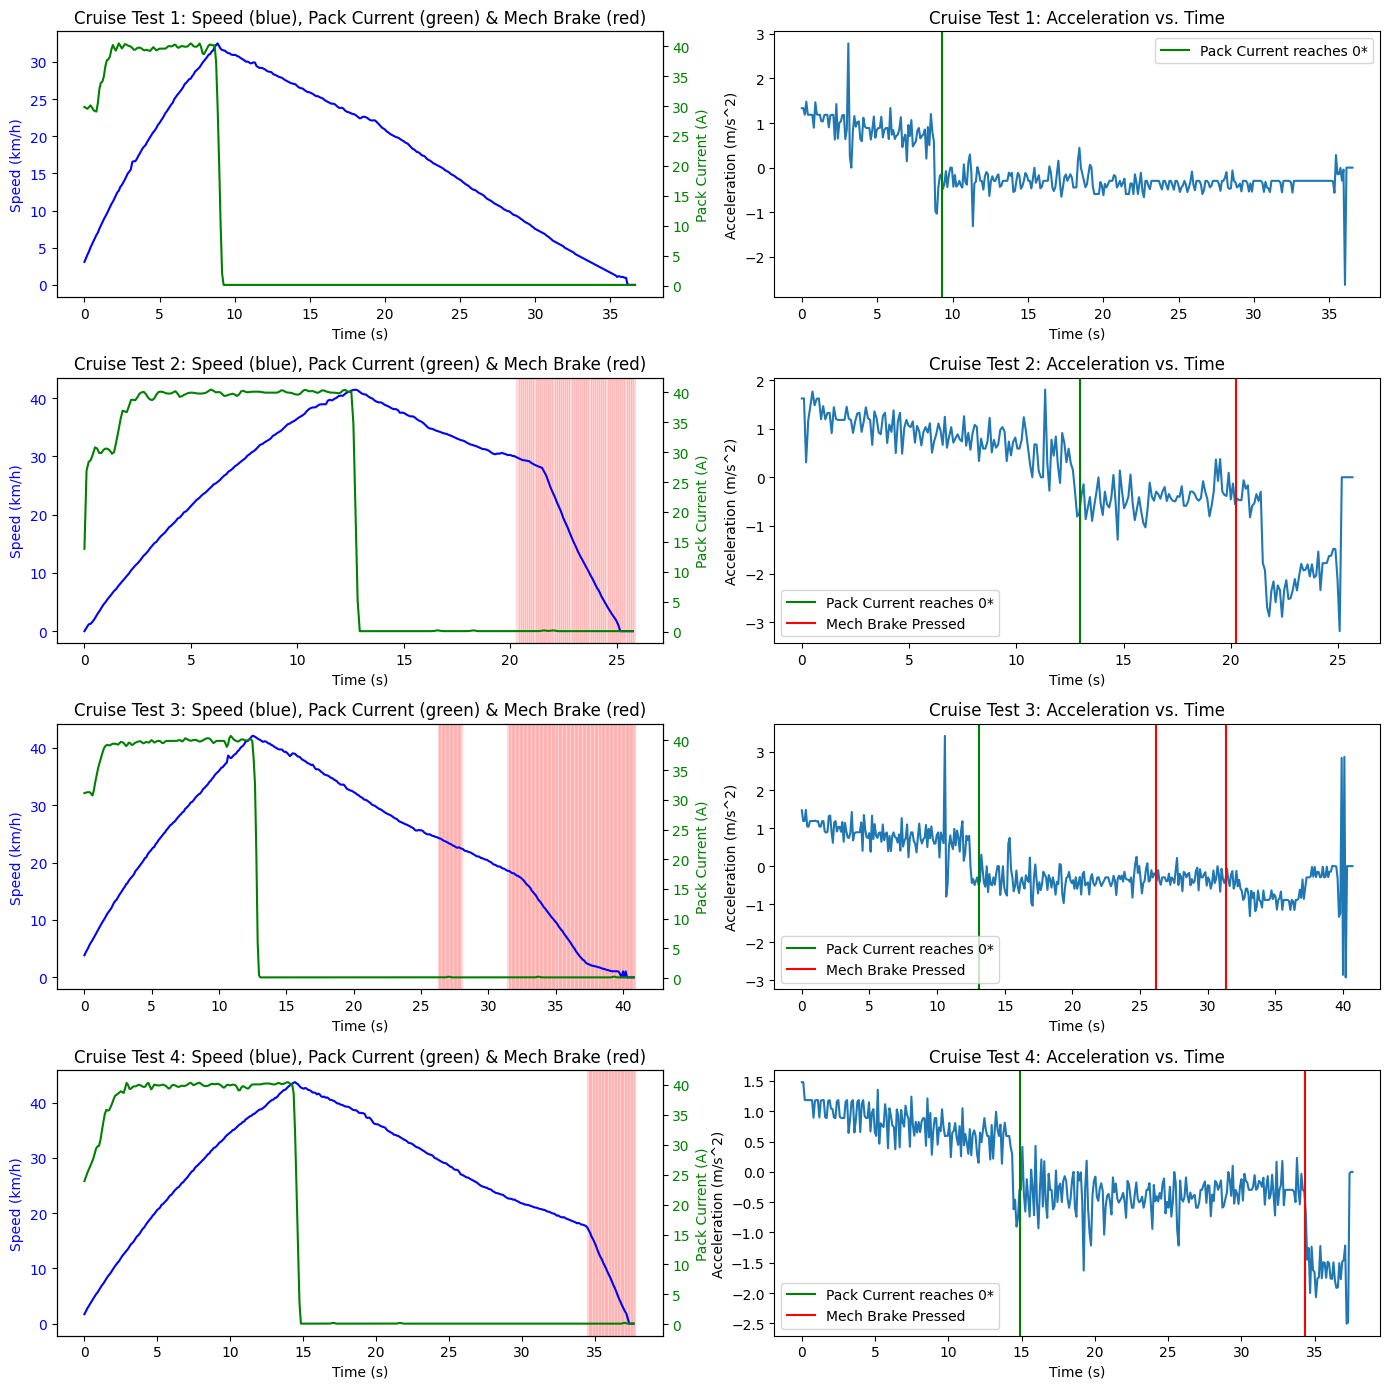

In [4]:
KMH_PER_MPS = 3.6
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for i, (speed, current, brake) in enumerate(zip(cruise_speeds, cruise_pack_currents, cruise_brake_presseds)):
    t_axis = speed.x_axis
    period = speed.period
    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS  # np.asarray(speed) turns TimeSeries into a basic np.ndarray, guaranteeing these operations work

    # Left plot: speed and pack current
    ax1 = axes[i, 0]
    ax1.plot(t_axis, speed, color='blue')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Speed (km/h)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_title(f"Cruise Test {i+1}: Speed (blue), Pack Current (green) & Mech Brake (red)")

    ax2 = ax1.twinx()
    ax2.plot(t_axis, current, color='green')
    ax2.set_ylabel('Pack Current (A)', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    for j, value in enumerate(brake):
        if value == 1:
            ax1.axvspan(t_axis[j], t_axis[j]+period, color='red', alpha=0.1)  # Highlight background when brake is pressed
    
    # Right plot: acceleration
    ax3 = axes[i, 1]
    ax3.plot(t_axis[:-1], acceleration)  # np.diff results in a 1 item shorter array

    cruise_start_time = np.where(current <= PACK_CURRENT_THRESHOLD)[0][0] * period
    ax3.axvline(cruise_start_time, c="green", label = "Pack Current reaches 0*") # star because current technically reaches PACK_CURRENT_THRESHOLD. I am assuming it is a sensor issue?

    brake_indices = np.where(brake > 0)[0]
    if brake_indices.size > 0:
        # identifying brake "groups" (i.e. each time the brake was pressed down) and plottng each group as a separate line. 
        gap_indices = np.where(np.diff(brake_indices) > 1)[0]
        brake_start_indices = np.concatenate([[brake_indices[0]], brake_indices[gap_indices + 1]])
        for j, brake_start_index in enumerate(brake_start_indices):
            brake_time = brake_start_index * period
            label = "Mech Brake Pressed" if j == 0 else "_nolegend_"
            ax3.axvline(brake_time, c="red", label = label)

    ax3.set_xlabel("Time (s)")
    ax3.set_ylabel("Acceleration (m/s^2)")
    ax3.legend()
    ax3.set_title(f"Cruise Test {i+1}: Acceleration vs. Time")

plt.tight_layout()
plt.show()


### Extracting the cruise test windows

The cruise test is the section of the run where the only forces acting on the car are rolling resistance and drag. This is the section where pack current drops to 0 and the mech brake as not been pressed yet. We'll extract this window below.

In [ ]:
cruise_window_speeds: list[TimeSeries] = []

for speed, current, brake in zip(cruise_speeds, cruise_pack_currents, cruise_brake_presseds):
    cruise_start_index = np.where(current <= PACK_CURRENT_THRESHOLD)[0][0]

    brake_indices = np.where(brake > 0)[0]
    if brake_indices.size == 0:
        zero_speed_indices = np.where(speed == 0)[0]
        cruise_end_index = zero_speed_indices[0]        # for runs where brake wasn't pressed, end the cruise when speed == 0
    else:    
        cruise_end_index = brake_indices[0]

    cruise_start_time = current.datetime_x_axis[cruise_start_index]
    cruise_end_time = brake.datetime_x_axis [cruise_end_index]

    cruise_window_speed: TimeSeries = speed.slice(cruise_start_time, cruise_end_time)
    cruise_window_speed.meta = speed.meta

    cruise_window_speeds.append(cruise_window_speed)

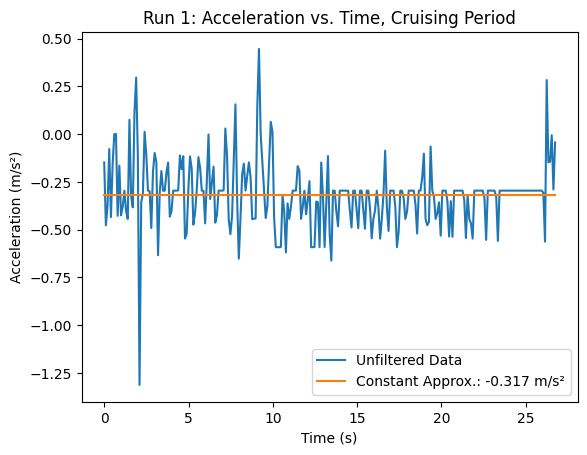

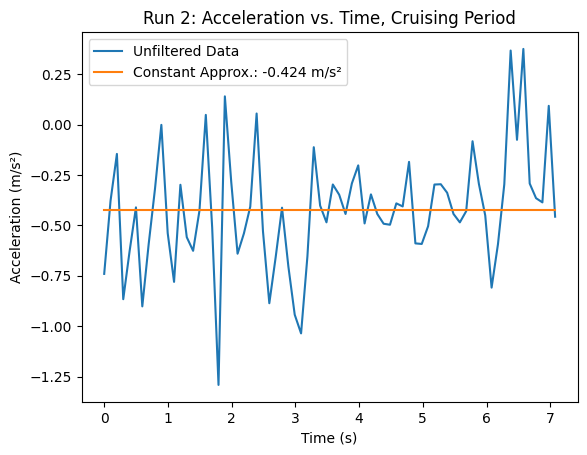

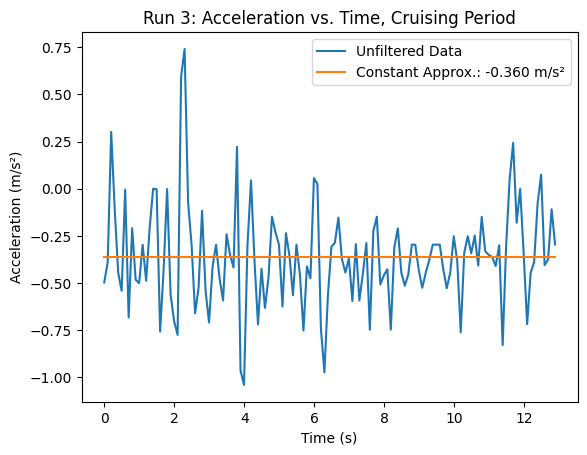

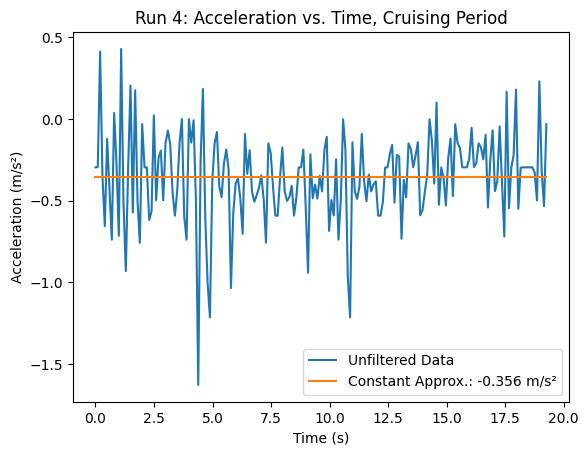

In [73]:
for i, speed in enumerate(cruise_window_speeds):
    period = speed.period
    t_axis = speed.x_axis

    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS
    mean_accel = np.mean(acceleration)
    constant_approx = np.ones(len(acceleration)) * mean_accel

    plt.plot(t_axis[:-1], acceleration, label="Unfiltered Data")
    plt.plot(t_axis[:-1], constant_approx, label=f"Constant Approx.: {mean_accel:.3f} m/s²")
    plt.title(f"Run {i+1}: Acceleration vs. Time, Cruising Period")
    plt.ylabel("Acceleration (m/s²)")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.show() 

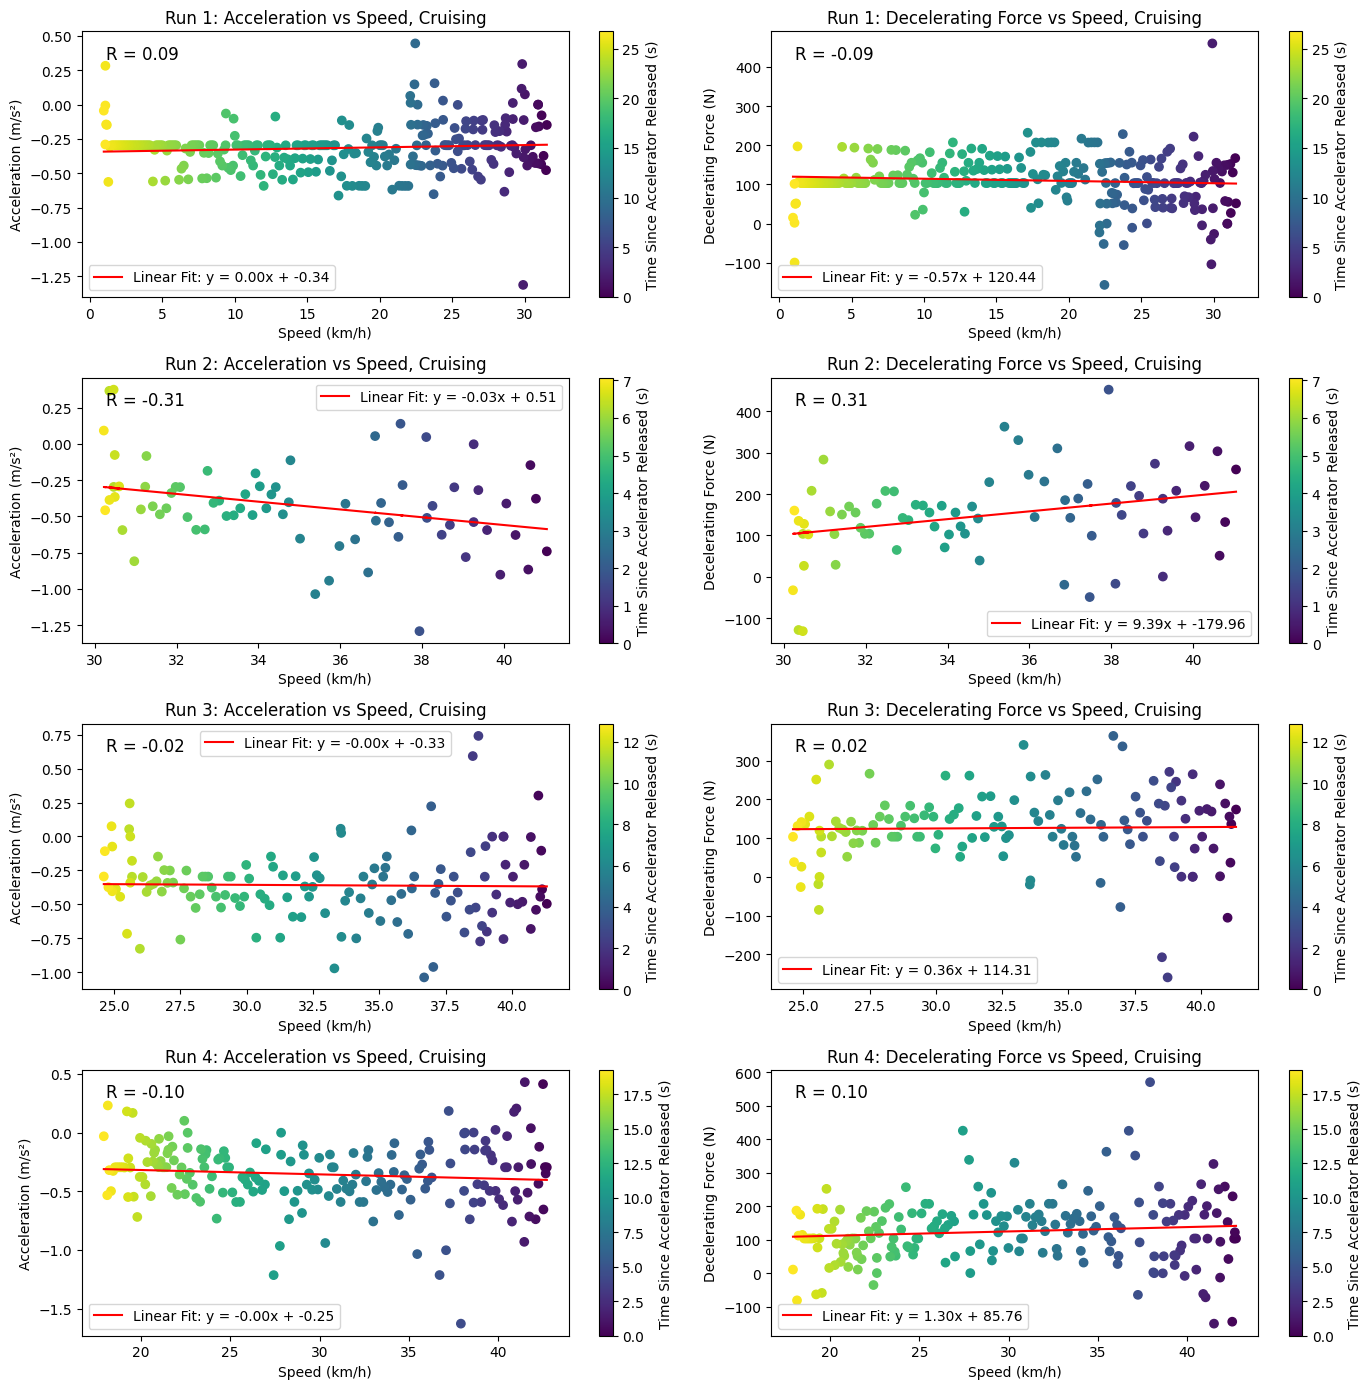

In [74]:
BRIGHTSIDE_MASS_KG = 350 # value taken from the 2025 analysis
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for i, speed in enumerate(cruise_window_speeds):
    t_axis = speed.x_axis
    period = speed.period

    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS
    force = BRIGHTSIDE_MASS_KG * acceleration * -1 # F = ma, and flip sign to get slowing force
    speed_without_last = speed[:-1]
    time_since_cruising = t_axis[:-1] - t_axis[0]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    for ax, y_data, y_label, title in [
        (ax1, acceleration, "Acceleration (m/s²)", f"Run {i+1}: Acceleration vs Speed, Cruising"),
        (ax2, force, "Decelerating Force (N)", f"Run {i+1}: Decelerating Force vs Speed, Cruising"),
    ]:  
    
        slope, intercept, r_value, _, _ = stats.linregress(speed_without_last, y_data)
        fit_line: np.ndarray = slope * np.asarray(speed_without_last) + intercept

        
        scatter = ax.scatter(speed_without_last, y_data, c=time_since_cruising)
        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        fig.colorbar(scatter, label="Time Since Accelerator Released (s)", ax=ax)

        ax.text(0.05, 0.95, f"R = {r_value:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top')

        ax.plot(speed_without_last, fit_line, color='red', label=f"Linear Fit: y = {slope:.2f}x + {intercept:.2f}")
        ax.legend()
    

plt.tight_layout()
plt.show()


### experimenting with smoothing

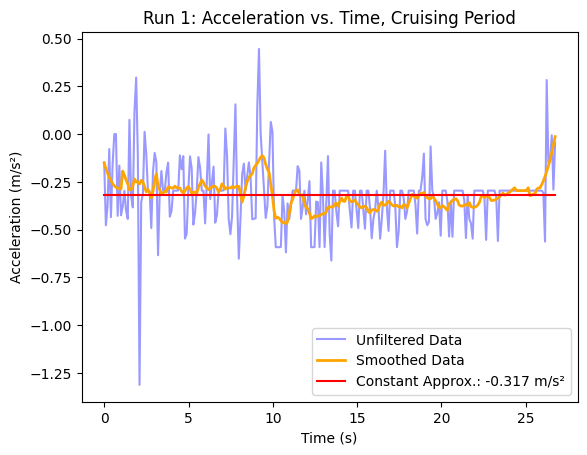

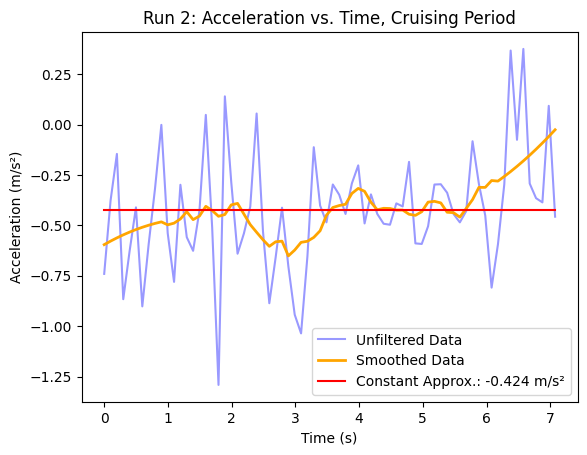

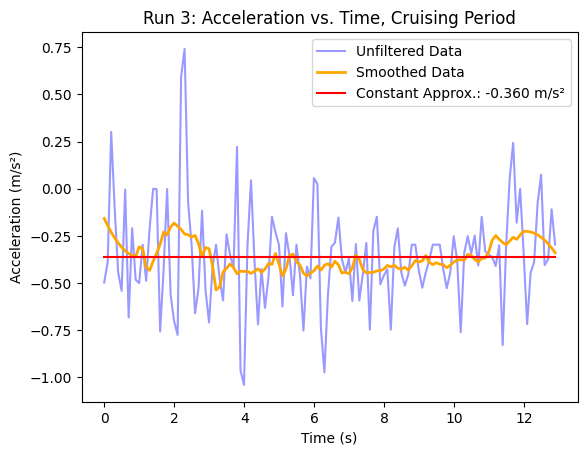

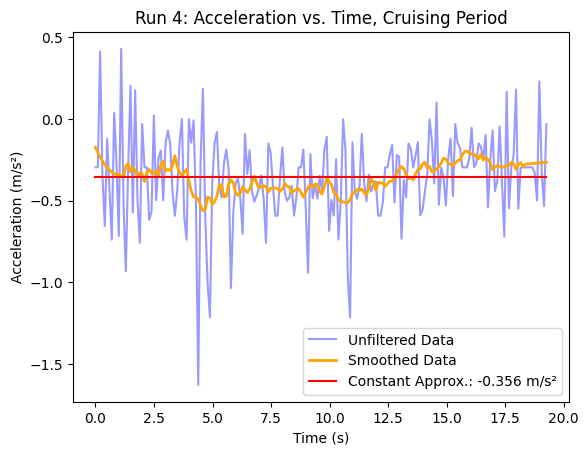

In [75]:
from scipy.signal import savgol_filter

SAVGOL_WINDOW = 21    # number of points in each window, must be odd — tune this
SAVGOL_POLY = 3       # polynomial order — 3 is standard

for i, speed in enumerate(cruise_window_speeds):
    period = speed.period
    t_axis = speed.x_axis

    speed_array: np.ndarray = np.asarray(speed)
    speed_smoothed: np.ndarray = savgol_filter(speed_array, SAVGOL_WINDOW, SAVGOL_POLY)

    acceleration_raw: np.ndarray = (np.diff(speed_array) / period) / KMH_PER_MPS
    acceleration_smooth: np.ndarray = (np.diff(speed_smoothed) / period) / KMH_PER_MPS

    mean_accel = np.mean(acceleration_raw)
    constant_approx = np.ones(len(acceleration_raw)) * mean_accel

    plt.plot(t_axis[:-1], acceleration_raw, label="Unfiltered Data", alpha=0.4, color='blue')
    plt.plot(t_axis[:-1], acceleration_smooth, label="Smoothed Data", color='orange', linewidth=2)
    plt.plot(t_axis[:-1], constant_approx, label=f"Constant Approx.: {mean_accel:.3f} m/s²", color='red')
    plt.title(f"Run {i+1}: Acceleration vs. Time, Cruising Period")
    plt.ylabel("Acceleration (m/s²)")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.show()

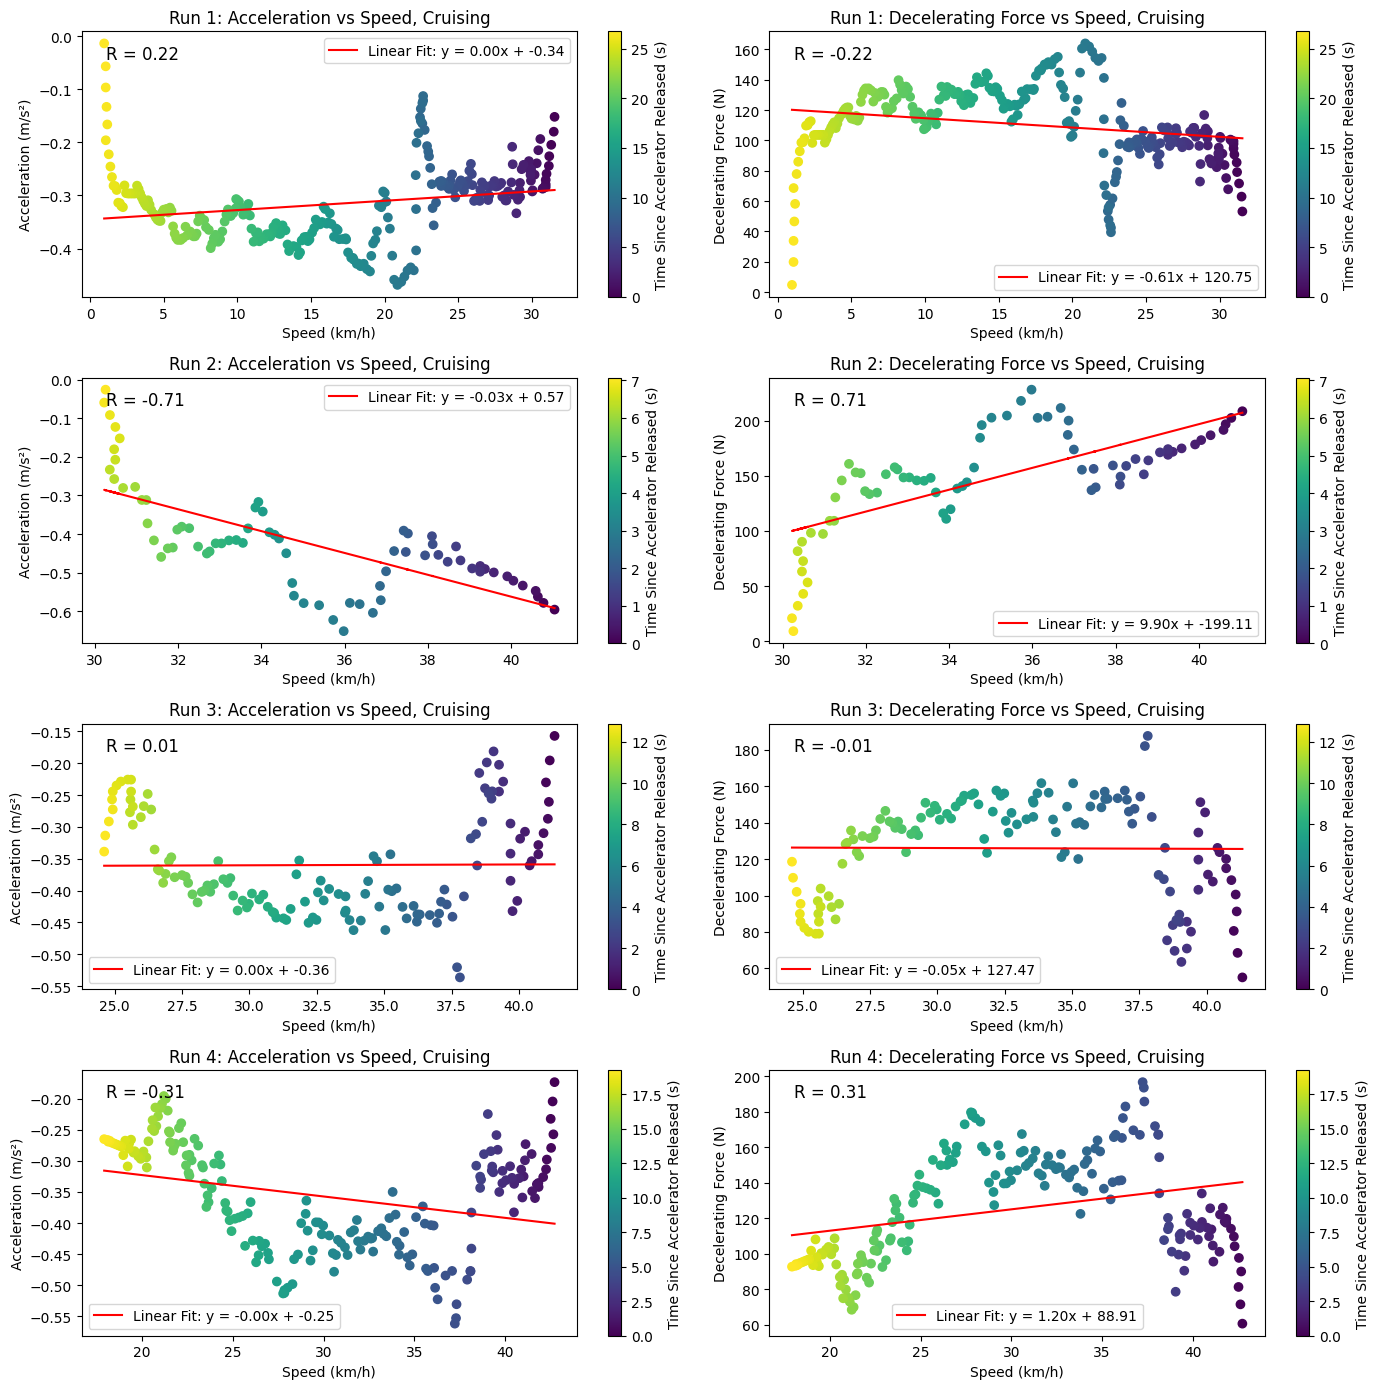

In [76]:
BRIGHTSIDE_MASS_KG = 350
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, speed in enumerate(cruise_window_speeds):
    t_axis = speed.x_axis
    period = speed.period

    speed_array: np.ndarray = np.asarray(speed)
    speed_smoothed: np.ndarray = savgol_filter(speed_array, SAVGOL_WINDOW, SAVGOL_POLY)

    # use smoothed speed for acceleration to reduce noise
    acceleration: np.ndarray = (np.diff(speed_smoothed) / period) / KMH_PER_MPS
    force: np.ndarray = BRIGHTSIDE_MASS_KG * acceleration * -1
    speed_without_last: np.ndarray = speed_array[:-1]           # km/h, for x axis
    time_since_cruising: np.ndarray = t_axis[:-1] - t_axis[0]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    for ax, y_data, y_label, title in [
        (ax1, acceleration, "Acceleration (m/s²)", f"Run {i+1}: Acceleration vs Speed, Cruising"),
        (ax2, force, "Decelerating Force (N)", f"Run {i+1}: Decelerating Force vs Speed, Cruising"),
    ]:
        slope, intercept, r_value, _, _ = stats.linregress(speed_without_last, y_data)
        fit_line: np.ndarray = slope * speed_without_last + intercept

        scatter = ax.scatter(speed_without_last, y_data, c=time_since_cruising)
        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        fig.colorbar(scatter, label="Time Since Accelerator Released (s)", ax=ax)
        ax.text(0.05, 0.95, f"R = {r_value:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
        ax.plot(speed_without_last, fit_line, color='red', label=f"Linear Fit: y = {slope:.2f}x + {intercept:.2f}")
        ax.legend()
        

plt.tight_layout()
plt.show()

### experimenting with IMU acceleration

In [ ]:
cruise_imu_zs: list[TimeSeries] = []
for start, stop in zip(START_TIMES, STOP_TIMES):
    client = DBClient()
    imu_z: TimeSeries = client.query_time_series(start=start, stop=stop, field="Acceleration_Z")
    cruise_imu_zs.append(imu_z)

# period of time where car is not moving
STATIC_START_TIME = datetime.fromisoformat("2026-04-02T20:04:00Z")
STATIC_STOP_TIME = datetime.fromisoformat("2026-04-02T20:07:00Z")
# imu_z_static: TimeSeries = client.query_time_series(start=STATIC_START_TIME, stop=STATIC_STOP_TIME, field="Acceleration_Z")

# z_static_accel = np.mean(imu_z_static)
# zeroed_imu_z = imu_z - z_static_accel

# cruising_test_start_utc = time(14 + utc_offset_h, 56)
# cruising_test_stop_utc = time(14 + utc_offset_h, 57)

# G = 9.81

# imu_cruising_acceleration = zeroed_imu_z[cruising_slice_i:cruising_slice_f]/1000*G

ApiException: (400)
Reason: Bad Request
HTTP response headers: HTTPHeaderDict({'Server': 'nginx/1.27.1', 'Date': 'Sat, 23 May 2026 20:55:35 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Vary': 'Accept-Encoding', 'X-Influxdb-Build': 'OSS', 'X-Influxdb-Version': 'v2.7.1', 'X-Platform-Error-Code': 'invalid'})
HTTP response body: b'{"code":"invalid","message":"error in building plan while starting program: cannot query an empty range"}'
